 #  Job Market Intelligence: An EDA of AmbitionBox Data

**Problem statement**
1. Which sectors and locations contribute most to job opportunities?
2. Does company rating influence hiring volume?
3. Is the job market evenly distributed or concentrated?
4. Do company reviews or popularity impact salary levels?
5. Which type of companies offer the most opportunities?

### Objective of this Project

1. Identify where job opportunities are most concentrated (companies, sectors, locations)
2. Analyze key factors influencing hiring demand (ratings, reviews, company size)
3. Explore relationships between company reputation and job availability
4. Understand sector-wise and city-wise job market trends
5. Provide data-driven insights to help candidates make better career decisions

### import libraries  

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



### Step 1: Load Dataset


In [23]:
Original_df=pd.read_csv("C:/Users/iamhe/Downloads/Web ambitionbox dataset.xls")
Original_df

,Company_names,Ratings,Reviews_count,Salary_count,Interview_count,Jobs_count,Company_sector,Locations,Benefits_count,Page_num
0,TCS,3.3,1.1L,9.9L,11.8k,3.5k,IT Services & Consulting,Bengaluru +441 other locations,10.6k,1
1,Accenture,3.7,72.6k,6.6L,9.3k,28.5k,IT Services & Consulting,Bengaluru +257 other locations,6.7k,1
2,Wipro,3.6,64.5k,4.8L,6.8k,421,IT Services & Consulting,Hyderabad +371 other locations,4.6k,1
3,Cognizant,3.7,60.7k,6L,6.4k,464,IT Services & Consulting,Hyderabad +233 other locations,5.5k,1
4,Capgemini,3.7,52.4k,4.8L,5.5k,2.6k,IT Services & Consulting,Bengaluru +182 other locations,3.7k,1
...,...,...,...,...,...,...,...,...,...,...
2975,Johnson Controls Hitachi Air Conditioning,3.6,367,1.6k,23,--,Consumer Electronics & Appliances,Ahmedabad +37 other locations,3,149
2976,Navi Technologies,3.0,367,2.2k,67,17,FinTech,Bengaluru +17 other locations,15,149
2977,RedBus,4.1,366,2k,42,5,Internet,Bengaluru +21 other locations,48,149
2978,Slice,3.2,366,2.2k,53,8,Banking,Bengaluru +39 other locations,6,149


In [24]:
df=Original_df.copy()


### Step 1: Check Data Issues
In this step, we check:

Data types

Missing values

Duplicate records

In [26]:
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2980 entries, 0 to 2979
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Company_names    2980 non-null   object 
 1   Ratings          2979 non-null   float64
 2   Reviews_count    2980 non-null   object 
 3   Salary_count     2980 non-null   object 
 4   Interview_count  2980 non-null   object 
 5   Jobs_count       2980 non-null   object 
 6   Company_sector   2980 non-null   object 
 7   Locations        2962 non-null   object 
 8   Benefits_count   2980 non-null   object 
 9   Page_num         2980 non-null   int64  
dtypes: float64(1), int64(1), object(8)
memory usage: 232.9+ KB


Company_names       0
Ratings             1
Reviews_count       0
Salary_count        0
Interview_count     0
Jobs_count          0
Company_sector      0
Locations          18
Benefits_count      0
Page_num            0
dtype: int64

In [35]:
df['Ratings'].fillna(df['Ratings'].mean(), inplace=True)
df['Locations'].fillna(df['Locations'].mode()[0], inplace=True)
df.isna().sum()

C:\Users\iamhe\AppData\Local\Temp\ipykernel_12832\2618200715.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Ratings'].fillna(df['Ratings'].mean(), inplace=True)
C:\Users\iamhe\AppData\Local\Temp\ipykernel_12832\2618200715.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.


Company_names      0
Ratings            0
Reviews_count      0
Salary_count       0
Interview_count    0
Jobs_count         0
Company_sector     0
Locations          0
Benefits_count     0
Page_num           0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

### Observation
The dataset contains:

Missing values

Data has Noise

Incorrect data types

No Duplicate rows

Now we will clean them step by step.

In [36]:
df.sample(5)

,Company_names,Ratings,Reviews_count,Salary_count,Interview_count,Jobs_count,Company_sector,Locations,Benefits_count,Page_num
1114,Jubilant Pharmova,3.7,946,3.3k,61,32,Pharma,Noida +61 other locations,113,56
1651,BankBazaar,3.3,648,2.9k,61,9,FinTech,Chennai +15 other locations,62,83
1424,Padget Electronics,3.8,741,2.7k,78,--,Electronics Manufacturing,Noida +17 other locations,24,72
300,VVDN Technologies,3.6,2.9k,13.7k,259,13,IT Services & Consulting,Gurugram +49 other locations,127,16
864,KIMS Hospital,3.8,1.2k,3.6k,61,4,Healthcare,Hyderabad +60 other locations,78,44


### Step 2: Remove Noise From Data
In this step, Remove Noise:

In [37]:
df["Salary_count"] = df["Salary_count"].str.lower().str.replace("l", "")
df["Jobs_count"] = df["Jobs_count"].str.replace("k", "000")
df["Jobs_count"] = pd.to_numeric(df["Jobs_count"], errors="coerce")

df["Salary_count"] = df["Salary_count"].str.replace("k", "000")
df["Salary_count"] = pd.to_numeric(df["Salary_count"], errors="coerce")


df["Reviews_count"] = df["Reviews_count"].str.replace("k", "000")
df["Reviews_count"] = pd.to_numeric(df["Reviews_count"], errors="coerce")

In [40]:
df = df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2249 entries, 1 to 2979
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Company_names    2249 non-null   object 
 1   Ratings          2249 non-null   float64
 2   Reviews_count    2249 non-null   float64
 3   Salary_count     2249 non-null   float64
 4   Interview_count  2249 non-null   object 
 5   Jobs_count       2249 non-null   float64
 6   Company_sector   2249 non-null   object 
 7   Locations        2249 non-null   object 
 8   Benefits_count   2249 non-null   object 
 9   Page_num         2249 non-null   int64  
dtypes: float64(4), int64(1), object(5)
memory usage: 193.3+ KB


In [43]:
df["Locations"]=df["Locations"].str.split(" ").str[0]

In [44]:
df.sample()

,Company_names,Ratings,Reviews_count,Salary_count,Interview_count,Jobs_count,Company_sector,Locations,Benefits_count,Page_num
1382,Fidelity International,3.6,762.0,5.7,60,98.0,Financial Services,Gurugram,82,70


### Step 3: Check Null and Removing them
In this step, we check:

Missing values

Filling With Mean


In [45]:
df.isnull().sum()

Company_names      0
Ratings            0
Reviews_count      0
Salary_count       0
Interview_count    0
Jobs_count         0
Company_sector     0
Locations          0
Benefits_count     0
Page_num           0
dtype: int64

In [46]:
df["Jobs_count"].fillna(df["Jobs_count"].mean(), inplace=True)


C:\Users\iamhe\AppData\Local\Temp\ipykernel_12832\1348224165.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Jobs_count"].fillna(df["Jobs_count"].mean(), inplace=True)


In [49]:
df.shape

(2249, 10)

### Step 4: Check Data Issues
In this step, we check:

Now , Store Clean File in Excel File

In [18]:
df.to_excel("Excel_Cleaned_ambition.xlsx",index=False)

### Step 5: Now, We Move Toward to EDA 
In this step, we check:

The Theme customization

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

# =========================
# 🎯 MASTER STYLE
# =========================
sns.set_theme(
    style="whitegrid",
    context="talk",
    font_scale=1.0   # balanced for screen fit
)

# =========================
# 📊 FIGURE SETTINGS (SCREEN FRIENDLY)
# =========================
plt.rcParams["figure.figsize"] = (10,6)   # fits screen perfectly
plt.rcParams["figure.dpi"] = 100          # normal zoom (no overflow)
plt.rcParams["savefig.dpi"] = 300         # high quality for export

# =========================
# 🔤 FONT & TEXT
# =========================
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["axes.labelweight"] = "medium"

plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

# =========================
# 🧱 AXES & SPINES
# =========================
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# =========================
# 🌐 GRID (SUBTLE)
# =========================
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["grid.linestyle"] = "--"

# =========================
# 🎨 COLOR PALETTE
# =========================
sns.set_palette("viridis")

# =========================
# 📌 LEGEND
# =========================
plt.rcParams["legend.fontsize"] = 10
plt.rcParams["legend.frameon"] = False

# =========================
# ✨ BACKGROUND
# =========================
plt.rcParams["axes.facecolor"] = "#f9f9f9"
plt.rcParams["figure.facecolor"] = "white"

### Step 6 :  Exploratory Data Analysis (EDA)
## Top 10 Companies Driving Job Market Demand

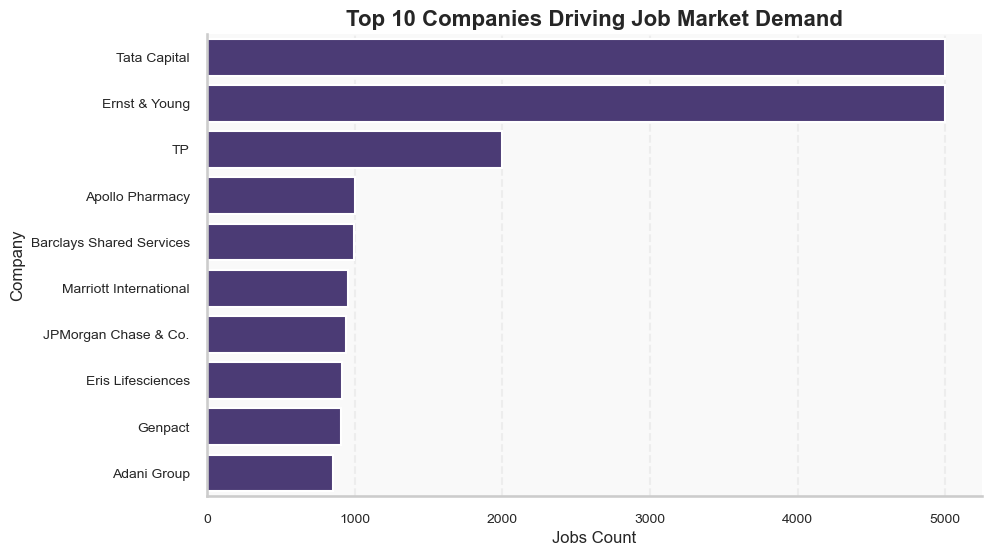

In [54]:
top_companies = df.sort_values("Jobs_count", ascending=False).head(10)

sns.barplot(data=top_companies, y="Company_names", x="Jobs_count")
plt.title("Top 10 Companies Driving Job Market Demand")
plt.xlabel("Jobs Count")
plt.ylabel("Company")
plt.show()

### Insight
Job demand is highly concentrated among a few top companies, with Ernst & Young and Tata Capital dominating hiring<br>
highlighting a winner-takes-most job market.

In [93]:
df.columns

Index(['Company_names', 'Ratings', 'Reviews_count', 'Salary_count',
       'Interview_count', 'Jobs_count', 'Company_sector', 'Locations',
       'Benefits_count', 'Page_num', 'Score', 'Jobs_log', 'Reviews_group',
       'Rating_group'],
      dtype='object')

## Top Cities with Highest Job Opportunities

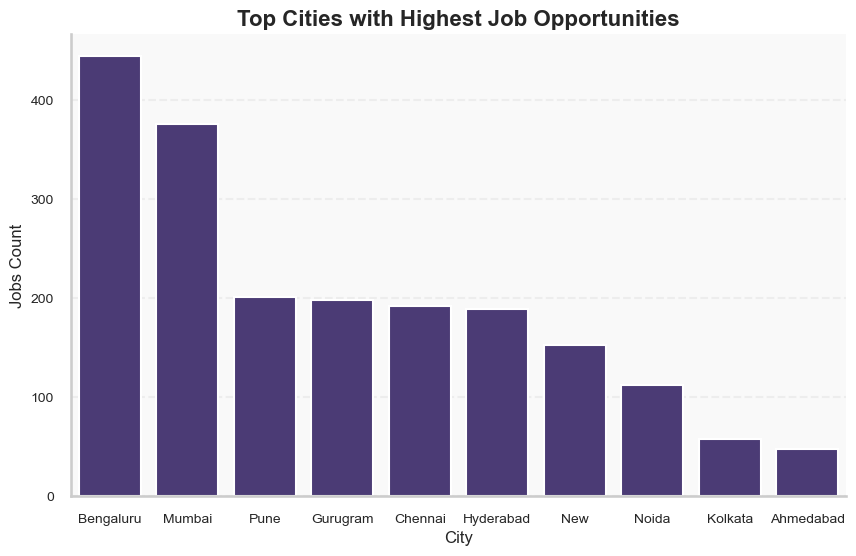

In [57]:
top_cities = df["Locations"].value_counts().head(10)

sns.barplot(x=top_cities.index, y=top_cities.values)
plt.title("Top Cities with Highest Job Opportunities")
plt.xlabel("City")
plt.ylabel("Jobs Count")
plt.show()

### Insight
Bengaluru and Mumbai dominate job opportunities, while other cities show a gradual decline with fewer openings.<br>
Job opportunities are geographically concentrated
Metro cities dominate due to:<br>
IT hubs<br>
Corporate presence

### Sector-wise Job Share

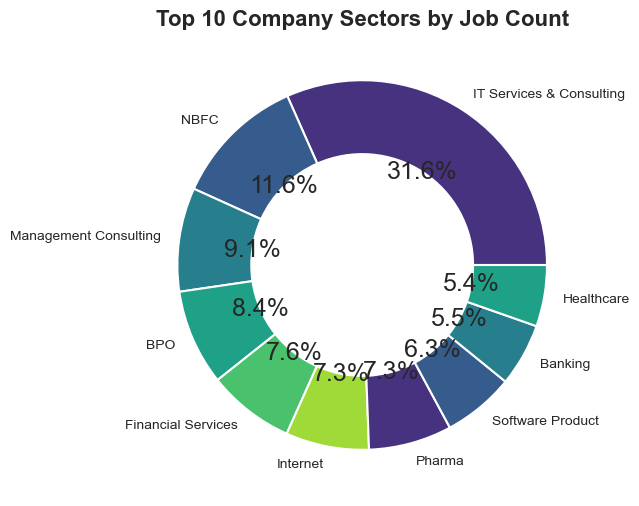

In [65]:
top_sectors = df.groupby('Company_sector')['Jobs_count'].sum() \
                .sort_values(ascending=False) \
                .head(10)
plt.pie(
    top_sectors.values,
    labels=top_sectors.index,
    autopct="%1.1f%%",
    wedgeprops={"width":0.4}
)
plt.title("Top 10 Company Sectors by Job Count")
plt.show() 

### Insight
IT Services & Consulting dominates the job market with the highest share, 
indicating a strong concentration of opportunities in the tech-driven sector.<br>
Tech sector is the primary driver of employment<br>
Other sectors contribute less → uneven distribution

## Number of Companies by Sector

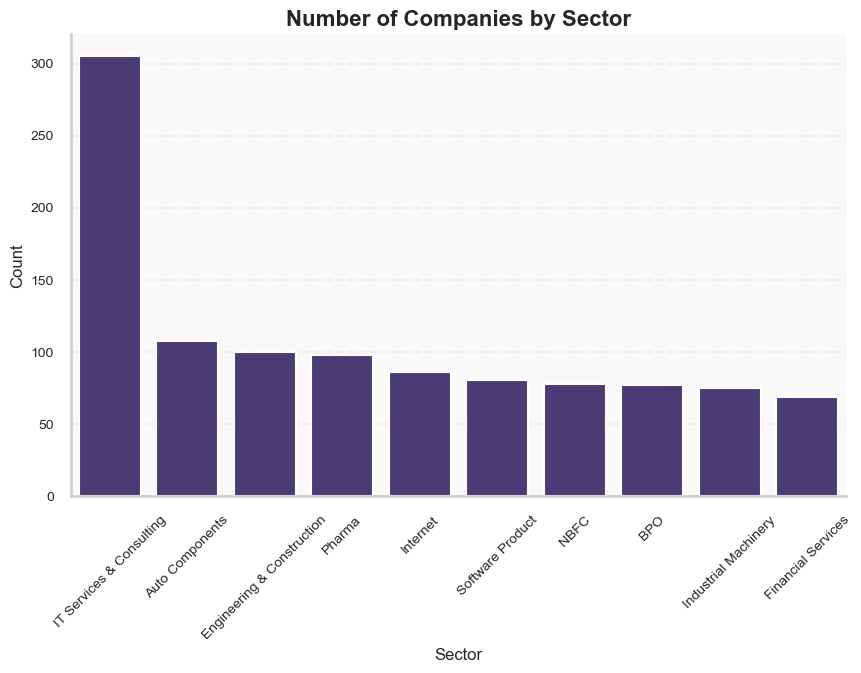

In [66]:
sns.countplot(
    x=df["Company_sector"],
    order=df["Company_sector"].value_counts().head(10).index
)

plt.title("Number of Companies by Sector")
plt.xlabel("Sector")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

## Insight
IT Services & Consulting leads significantly in job count<br>
Higher number of companies → higher job availability<br>
Strong correlation between sector size & job demand

## Distribution of Company Ratings

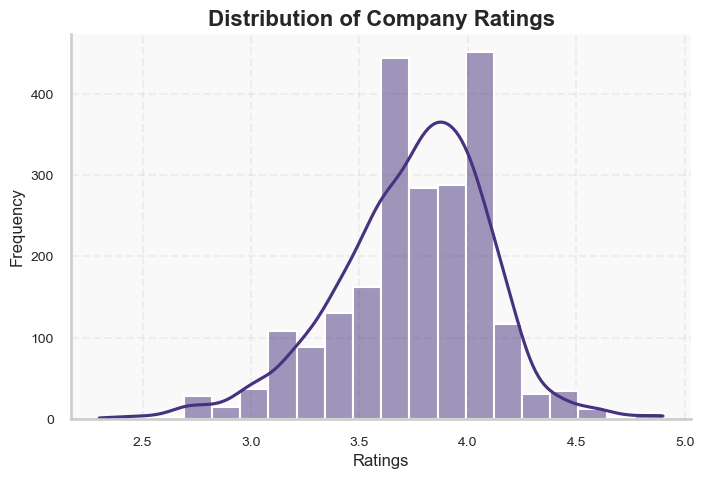

In [69]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Ratings"],
    kde=True,
    bins=20
)

plt.title("Distribution of Company Ratings")
plt.xlabel("Ratings", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.show()

## Insight
Ratings mostly between 3.5 – 4.2<br>
Most companies have moderately high ratings<br>
Very low-rated companies are rare

## Reviews vs Salary Transparency

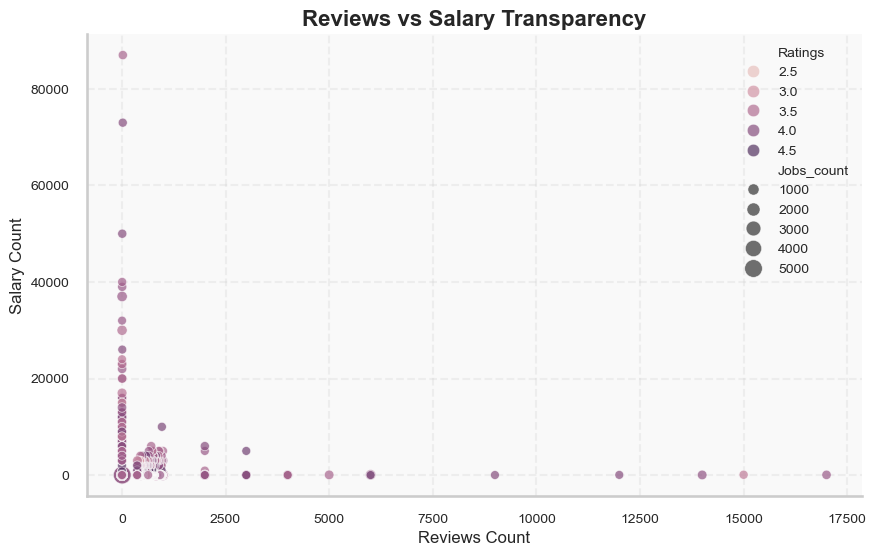

In [70]:
sns.scatterplot(
    data=df,
    x="Reviews_count",
    y="Salary_count",
    size="Jobs_count",
    hue="Ratings",
    alpha=0.7
)

plt.title("Reviews vs Salary Transparency")
plt.xlabel("Reviews Count")
plt.ylabel("Salary Count")
plt.show()

## Insight
No strong relationship between reviews & salary<br>
Popular companies (more reviews) don’t guarantee higher salaries<br>
Salary depends more on:<br>
Role<br>
Industry<br>
Skills

## Job Distribution Across Rating Levels

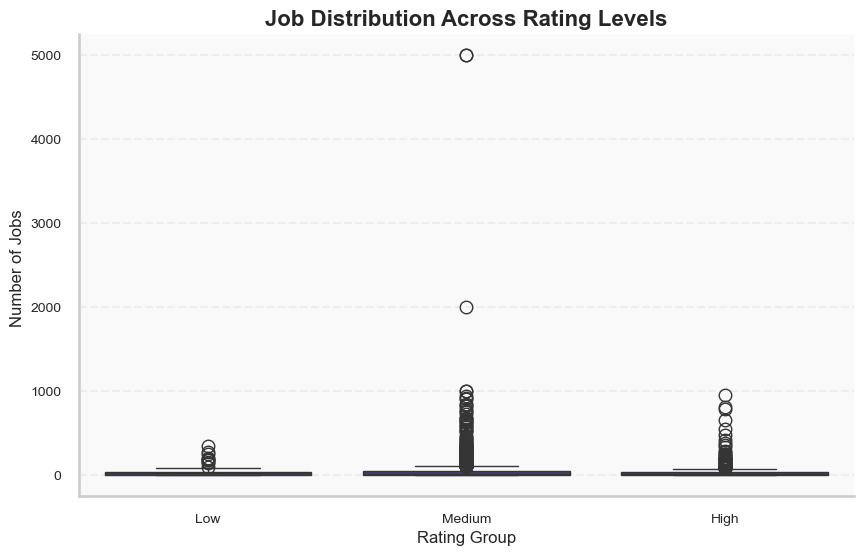

In [72]:

df["Rating_group"] = pd.cut(
    df["Ratings"],
    bins=[0, 3, 4, 5],
    labels=["Low", "Medium", "High"]
)


sns.boxplot(data=df, x="Rating_group", y="Jobs_count")

plt.title("Job Distribution Across Rating Levels")
plt.xlabel("Rating Group")
plt.ylabel("Number of Jobs ")
plt.show()

## Insight
Medium-rated companies have highest job count variability<br>
Most hiring comes from mid-rated companies<br>
There are many outliers (few companies hiring a lot)<br>

## Top Companies Based on Overall Score

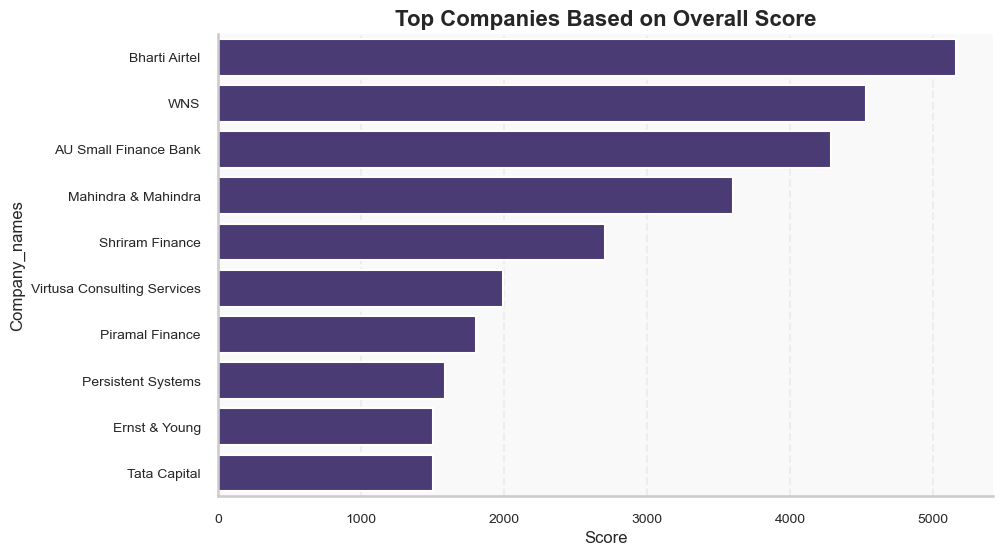

In [74]:
df["Score"] = (
    df["Ratings"] * 0.4 +
    df["Jobs_count"] * 0.3 +
    df["Reviews_count"] * 0.3
)

top_score = df.sort_values("Score", ascending=False).head(10)

sns.barplot(data=top_score, y="Company_names", x="Score")
plt.title("Top Companies Based on Overall Score")
plt.show()

## Insight 
Medium-rated companies have highest job count<br>
Hiring is not limited to top-rated companies<br>
Mid-level companies are most active in recruitment

# Final Step : Key Insight and Conclusion

# Key Insights (EDA)
Hiring is highly skewed → few companies dominate job openings<br>
Company ratings have weak impact on hiring volume<br>
Majority of companies fall in 3.0–4.0 rating range<br>
Job opportunities are sector-driven, not evenly distributed<br>
Data cleaning was crucial due to missing & inconsistent values<br>

#  Conclusion  (EDA)
Hiring trends are not evenly distributed across companies<br>
Company scale plays a bigger role than ratings in hiring<br>
Certain sectors act as major job generators<br>
Real-world datasets require data cleaning and preprocessing<br>
Data analysis helps in identifying patterns for better decision-making<br>

# Thankyou Everyone!!!!!